In [1]:
import pandas as pd
import numpy as np
import os
import perturbo

import mudata as md
import anndata as ad
import seaborn as sns
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch
import scvi
scvi.settings.seed = 0

/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
Global seed set to 0


Set training configuration and access to data

In [2]:

data_dir = "/work/data/SHARED_DATA/genome_wide_Perturb-seq/"
batch_size=16384 # 2^14 

# smoke_test=True # only run a tiny subset of genes
smoke_test=False # run full analysis

if torch.cuda.is_available():
    # use_gpu=True
    # torch.set_default_tensor_type('torch.cuda.FloatTensor')
    print("training using GPU")
    accelerator="gpu"
else:
    accelerator="cpu"


training using GPU


In [3]:
chunk_number=1
mdata_file = f"{data_dir}/K562_gwps_raw_singlecell.chunk_{chunk_number:02d}.h5mu"
mdata = md.read(mdata_file)

# batch_size=None
mdata

MuData object with n_obs × n_vars = 1989578 × 13249
  2 modalities
    rna:	1989578 x 2062
      obs:	'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
      var:	'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'
    grna:	1989578 x 11187
      var:	'target'

In [ ]:
mdata.grna

In [7]:
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="gem_group",
    library_size_key="UMI_count",
    continuous_covariates_keys=["mitopercent"],
    # var_by_element_key="element_tested",
    # perturb_by_element_key="element_targeted",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood='lnnb', fit_lib_size=False, fit_dispersion=False)
model.view_anndata_setup()


Anndata setup with scvi-tools version 1.0.2.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': 'gem_group',
│   'var_by_element_key': None,
│   'perturb_by_element_key': None,
│   'library_size_key': 'UMI_count',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['mitopercent'],
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃    Summary Stat Key     ┃  Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│         n_batch         │   267   │
│         n_cells         │ 1989578 │
│ n_extra_continuous_covs │    1    │
│     n_perturbations     │  11187  │
│         n_vars          │  2062   │
└─────────────────────────┴─────────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
└───────────────────────┴──────────────────────────────────────────────────────┘

                    batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['gem_group'] │     1      │          0          │
│                        │     2      │          1          │
│                        │     3      │          2          │
│                        │     4      │          3          │
│                        │     5      │          4          │
│                        │     6      │          5          │
│                        │     7      │          6          │
│                        │     8      │          7          │
│                        │     9      │          8          │
│                        │     10     │          9          │
│                        │     11     │         10          │
│                        │     12     │         11          │
│                        │     13     │         12          │
│                        │     14     │         13          │
│                        │     15     │         14          │
│                        │     16     │         15          │
│                        │     17     │         16          │
│                        │     18     │         17          │
│                        │     19     │         18          │
│                        │     20     │         19          │
│                        │     21     │         20          │
│                        │     22     │         21          │
│                        │     23     │         22          │
│                        │     24     │         23          │
│                        │     25     │         24          │
│                        │     26     │         25          │
│                        │     27     │         26          │
│                        │     28     │         27          │
│                        │     29     │         28          │
│                        │     30     │         29          │
│                        │     31     │         30          │
│                        │     32     │         31          │
│                        │     33     │         32          │
│                        │     34     │         33          │
│                        │     35     │         34          │
│                        │     36     │         35          │
│                        │     37     │         36          │
│                        │     38     │         37          │
│                        │     39     │         38          │
│                        │     40     │         39          │
│                        │     41     │         40          │
│                        │     42     │         41          │
│                        │     43     │         42          │
│                        │     44     │         43          │
│                        │     45     │         44          │
│                        │     46     │         45          │
│                        │     47     │         46          │
│                        │     48     │         47          │
│                        │     49     │         48          │
│                        │     50     │         49          │
│                        │     51     │         50          │
│                        │     52     │         51          │
│                        │     53     │         52          │
│                        │     54     │         53          │
│                        │     55     │         54          │
│                        │     56     │         55          │
│                        │     57     │         56          │
│                        │     58     │         57          │
│                        │     59     │         58          │
│                        │     60     │         59          │
│                        │     6

extra_continuous_covs State 
          Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['mitopercent'] │
└──────────────────────────┘

In [11]:
# burn-in
pyro.clear_param_store()
# plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.96))}
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)
# model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)


In [ ]:
## fine-tune
# plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.99))}
# model.train(20, lr=0.1, batch_size=1024, use_gpu=use_gpu)
# model.train(100, lr=0.03, batch_size=1024, use_gpu=use_gpu)
# model.train(50, lr=0.01, batch_size=2048, use_gpu=use_gpu) 
# model.train(50, lr=0.05, batch_size=512, use_gpu=use_gpu)

model.train(20, lr=0.01, batch_size=16384, accelerator=accelerator) 
model.train(20, lr=0.001, batch_size=16384, accelerator=accelerator) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 3/10:  20%|██        | 2/10 [05:07<20:30, 153.83s/it, v_num=1, elbo_train=4.77e+9]

In [14]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

log_pooling.mu torch.Size([1])
batch_effect.mu torch.Size([48, 8563])
batch_effect.sigma torch.Size([48, 8563])
cont_cov_effect.mu torch.Size([3, 8563])
cont_cov_effect.sigma torch.Size([3, 8563])
multiplicative_noise.mu torch.Size([8563])
log_var_mean.mu torch.Size([8563])
log_var_disp.mu torch.Size([8563])
log_var_mean.sigma torch.Size([8563])
log_var_disp.sigma torch.Size([8563])
element_mean_lfc.mu torch.Size([2273, 8563])
element_mean_lfc.sigma torch.Size([2273, 8563])
element_disp_lfc.mu torch.Size([2273, 8563])
element_disp_lfc.sigma torch.Size([2273, 8563])
perturb_mean_lfc.mu torch.Size([2273, 8563])
perturb_mean_lfc.sigma torch.Size([2273, 8563])
perturb_disp_lfc.mu torch.Size([2273, 8563])
perturb_disp_lfc.sigma torch.Size([2273, 8563])


In [16]:
# model.save(f"gwps_model/", overwrite=False, save_anndata=True)

In [ ]:
# perturbo.PERTURBO.load("gwps_model/", use_gpu=True)
import os

In [17]:
# ?perturbo.PERTURBO.load
# ?model.save

In [19]:
lfc_threshold = 0 # ~ at least 10% upreg
# lfc_threshold = 0 # nonzero change
# gene_index=45


variance_eqtl = False

# lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril']
# lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)

# ### UNIVARIATE HYPOTHESIS TESTING
# if variance_eqtl:
#     q_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
#     q_sigma = lfc_cov[...,1,1].sqrt().detach().cpu().numpy()
# else:
#     q_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
#     q_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
# assert q_mu.shape == q_sigma.shape
q_mu, q_sigma = model.module.get_element_effects()
perturb_z_scores = q_mu/q_sigma
# p_val_1 = norm.sf(-lfc_threshold, loc=q_mu, scale=q_sigma)
# p_val_2 = norm.cdf(lfc_threshold, loc=q_mu, scale=q_sigma)
# perturb_p_vals = np.minimum(p_val_1, p_val_2)*2
# p_val_1 = norm.sf(-lfc_threshold, loc=q_mu, scale=q_sigma)
# p_val_2 = norm.cdf(lfc_threshold, loc=q_mu, scale=q_sigma)
# perturb_p_vals = np.minimum(p_val_1, p_val_2)*2

# perturb_p_vals=norm.sf(-lfc_threshold, loc=q_mu, scale=q_sigma)

In [20]:
perturb_z_scores.shape

(2273, 8563)

In [21]:
mdata['rna'].var

,gene_name,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano
gene_id,,,,,,,,,,,,
ENSG00000237491,LINC01409,chr1,778747,810065,gene_version10,+,31318,True,0.137594,0.380048,2.762105,1.049733
ENSG00000228794,LINC01128,chr1,825138,868202,gene_version9,+,43064,True,0.256720,0.520162,2.026184,1.053944
ENSG00000188976,NOC2L,chr1,944203,959309,gene_version11,-,15106,True,1.975144,1.707837,0.864665,1.476706
ENSG00000187961,KLHL17,chr1,960584,965719,gene_version14,+,5135,True,0.119593,0.353702,2.957540,1.046089
ENSG00000188290,HES4,chr1,998962,1000172,gene_version10,-,1210,True,0.249577,0.561933,2.251540,1.265214
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000278704,BX004987.1,GL000009.2,56140,58376,gene_version1,-,2236,True,0.241213,0.507266,2.102976,1.066768
ENSG00000274847,MAFIP,GL000194.1,53594,115055,gene_version1,-,61461,True,0.127525,0.361556,2.835168,1.025072
ENSG00000278384,AL354822.1,GL000218.1,51867,54893,gene_version1,-,3026,True,0.248814,0.516552,2.076062,1.072394


## Cluster perturbations by effect vectors

[0.16360465 0.14517128]


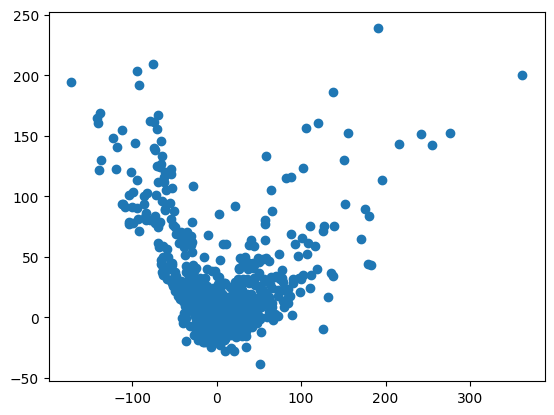

In [22]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

zdata = ad.AnnData(perturb_z_scores, obs=mdata['grna'].var, var=mdata['rna'].var)
# tsne = TSNE(n_components=2)
# tsne_results = tsne.fit_transform(perturb_z_scores)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(perturb_z_scores)
pca_result
print(pca.explained_variance_ratio_)
fig, ax = plt.subplots()
# ax = fig.add_subplot(projection='3d')
ax.scatter(pca_result[:,0], pca_result[:,1])


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2273 samples in 0.009s...
[t-SNE] Computed neighbors for 2273 samples in 1.245s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2273
[t-SNE] Computed conditional probabilities for sample 2000 / 2273
[t-SNE] Computed conditional probabilities for sample 2273 / 2273
[t-SNE] Mean sigma: 12.258591
[t-SNE] KL divergence after 250 iterations with early exaggeration: 118.530205
[t-SNE] KL divergence after 1000 iterations: 2.674631


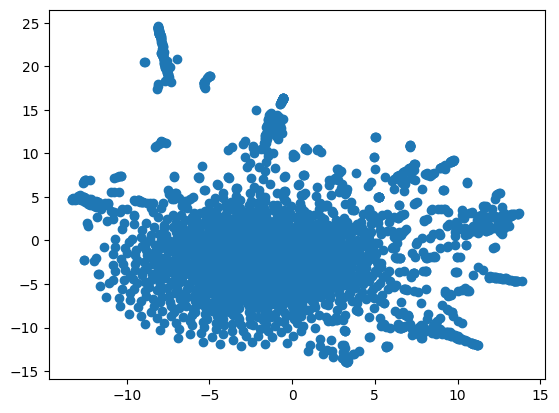

In [23]:
tsne = TSNE(n_components=2, verbose=1)
tsne_result = tsne.fit_transform(perturb_z_scores)
fig, ax = plt.subplots()
# ax = fig.add_subplot(projection='3d')
ax.scatter(tsne_result[:,0], tsne_result[:,1])


In [24]:
mdata['rna'].var

,gene_name,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano
gene_id,,,,,,,,,,,,
ENSG00000237491,LINC01409,chr1,778747,810065,gene_version10,+,31318,True,0.137594,0.380048,2.762105,1.049733
ENSG00000228794,LINC01128,chr1,825138,868202,gene_version9,+,43064,True,0.256720,0.520162,2.026184,1.053944
ENSG00000188976,NOC2L,chr1,944203,959309,gene_version11,-,15106,True,1.975144,1.707837,0.864665,1.476706
ENSG00000187961,KLHL17,chr1,960584,965719,gene_version14,+,5135,True,0.119593,0.353702,2.957540,1.046089
ENSG00000188290,HES4,chr1,998962,1000172,gene_version10,-,1210,True,0.249577,0.561933,2.251540,1.265214
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000278704,BX004987.1,GL000009.2,56140,58376,gene_version1,-,2236,True,0.241213,0.507266,2.102976,1.066768
ENSG00000274847,MAFIP,GL000194.1,53594,115055,gene_version1,-,61461,True,0.127525,0.361556,2.835168,1.025072
ENSG00000278384,AL354822.1,GL000218.1,51867,54893,gene_version1,-,3026,True,0.248814,0.516552,2.076062,1.072394


In [25]:
def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, columns=mdata['rna'].var['gene_name'], index=mdata['grna'].var['target'])
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="guide")
    )

# gwps_df = pd.merge(
#     make_long_df(perturb_z_scores, "z_value"),
#     make_long_df(perturb_p_vals, "p_value"),
# )

gwps_df=make_long_df(perturb_z_scores, "z_value")

In [26]:
gwps_df

,guide,gene,z_value
0,AAAS,LINC01409,-0.047410
1,AAMP,LINC01409,0.177677
2,AARS2,LINC01409,-0.289705
3,AARS,LINC01409,0.224998
4,AASDHPPT,LINC01409,-0.093127
...,...,...,...
19463694,non-targeting,AC004556.3,0.126279
19463695,non-targeting,AC004556.3,0.830549
19463696,non-targeting,AC004556.3,0.163410
19463697,non-targeting,AC004556.3,0.620983


In [27]:
perturb_z_score_df =  pd.DataFrame(data=perturb_z_scores, columns=mdata['rna'].var['gene_name'], index=mdata['grna'].var['target'])
perturb_z_score_df

gene_name,LINC01409,LINC01128,NOC2L,KLHL17,HES4,ISG15,SDF4,B3GALT6,UBE2J2,ACAP3,...,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,BX004987.1,MAFIP,AL354822.1,AC240274.1,AC004556.3
target,,,,,,,,,,,,,,,,,,,,,
AAAS,-0.047410,-0.418671,0.160924,-0.046601,0.986566,0.280114,-0.024255,-0.522091,-0.382072,-0.563001,...,-0.005282,-0.970025,-0.154286,-0.121408,-1.186602,0.079369,0.017257,0.270086,0.647694,0.293602
AAMP,0.177677,0.278063,-0.148337,-0.245042,-0.707892,0.413319,-0.093883,-0.017060,0.614275,-0.080478,...,-2.904418,-1.337168,-1.272382,-2.132127,0.281216,0.070631,-0.343328,-0.084413,-0.162400,0.311323
AARS2,-0.289705,-0.246872,0.091797,0.145914,0.401789,-0.548858,-0.662200,0.019440,0.215169,-0.102227,...,1.447750,-2.318205,1.409268,0.176559,0.791972,0.029797,0.210567,-0.199789,0.088700,0.482381
AARS,0.224998,-0.229869,-2.411555,-0.167882,-0.158584,0.347839,-0.112768,0.068488,-0.587034,-0.501932,...,-6.417962,-1.689879,-3.049478,-3.140373,0.376993,-0.059916,-0.225746,0.020040,-0.068721,-0.185642
AASDHPPT,-0.093127,-0.300557,0.064015,0.038351,0.214911,-0.512507,1.192776,0.470071,-0.228816,-0.027349,...,0.987447,-0.789192,0.645503,0.964378,-0.892349,-0.006216,-0.160983,-0.088430,0.014618,0.320117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
non-targeting,-0.120624,-0.222518,0.784394,0.084369,-0.297147,-0.341786,0.223569,-0.225041,0.297840,-1.494294,...,0.651359,-0.739992,0.320549,0.118801,-0.687170,0.053773,-0.573461,0.306634,0.298720,0.126279
non-targeting,0.152769,0.057954,-0.145890,-0.647960,-0.512661,-0.498236,-0.878585,-0.182871,-0.426490,0.192515,...,0.487410,-0.701579,0.036912,0.265079,-0.729446,-0.290295,-0.536254,0.605080,0.141265,0.830549
non-targeting,-0.598974,-0.682368,0.601549,-0.341928,-0.011296,-0.205201,0.038032,-1.135236,0.364351,0.320085,...,-0.038655,-0.745715,0.114759,0.098520,-0.145727,0.114653,0.064870,-0.292181,0.256388,0.163410


TO DO: look at gene expression distribution of HVGs

In [28]:
plot_grid_size = 100
gene_var = perturb_z_scores.std(axis=0).argsort()
hvg_idxs = gene_var[-plot_grid_size:]
plot_z_df = perturb_z_score_df.iloc[:,hvg_idxs]

pert_var = perturb_z_scores.std(axis=1).argsort()
hvp_idxs = pert_var[-plot_grid_size:]
plot_z_df = plot_z_df.iloc[hvp_idxs,:]


In [29]:
from scipy.spatial.distance import pdist, squareform
corr = np.corrcoef(perturb_z_scores)
# corr = squareform(pdist(perturb_z_scores, "cosine"))
corr_df = pd.DataFrame(data=corr,
                     columns=mdata['grna'].var['target'],
                     index=mdata['grna'].var['target'])

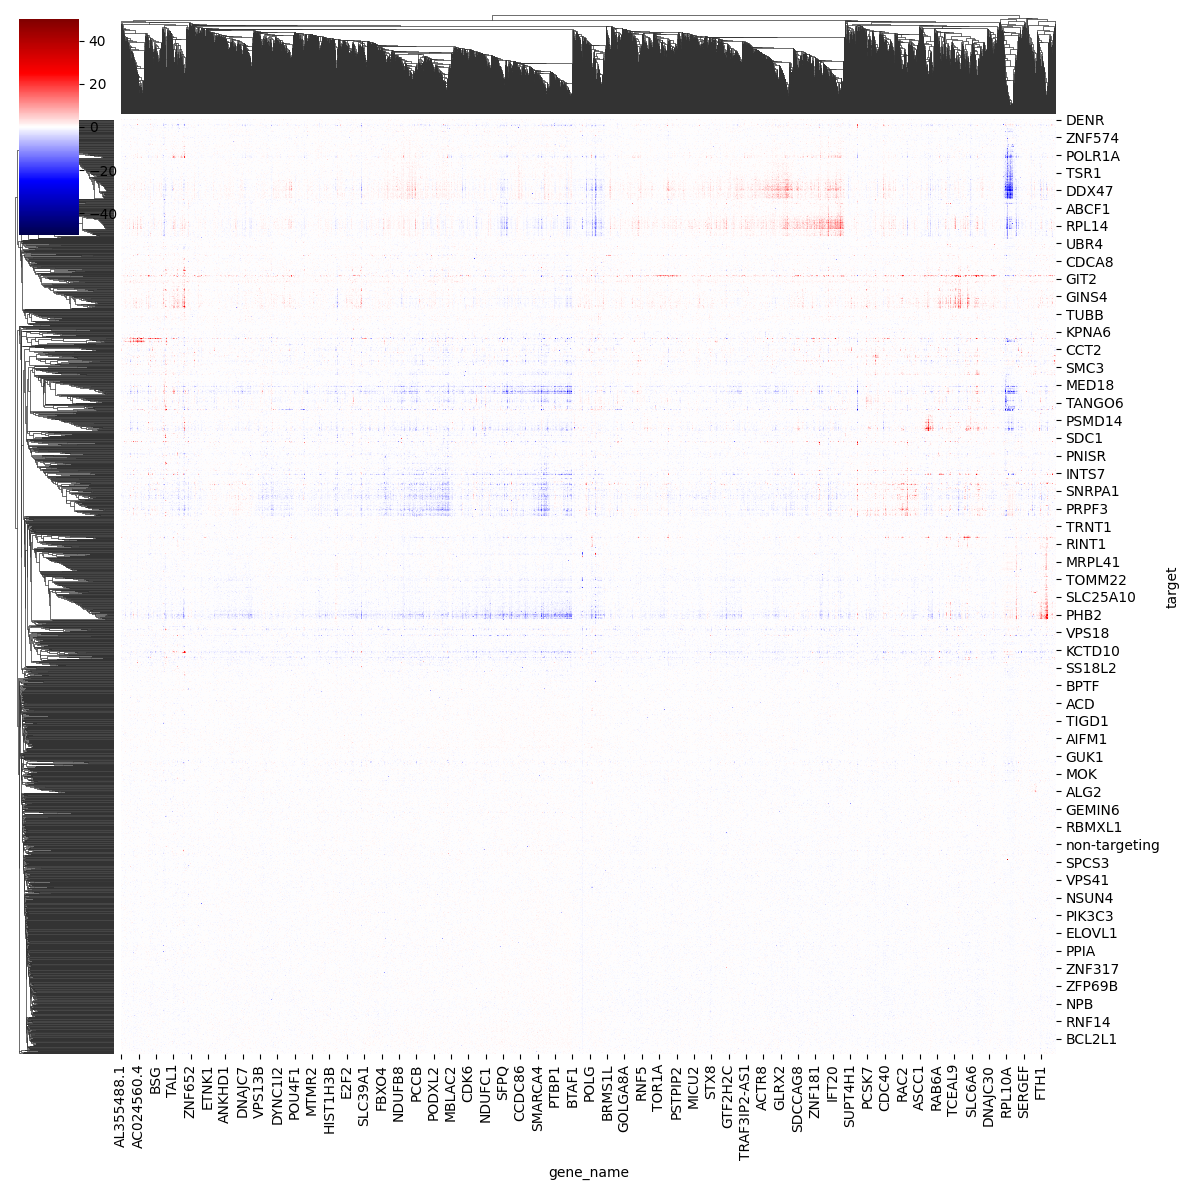

In [30]:
heatmap = sns.clustermap(perturb_z_score_df, metric="cosine", cmap="seismic", dendrogram_ratio=0.1, vmin=-50, vmax=50, figsize=(12,12))
heatmap.savefig("gwps_plots/zscore_heatmap_full.png", dpi=300)

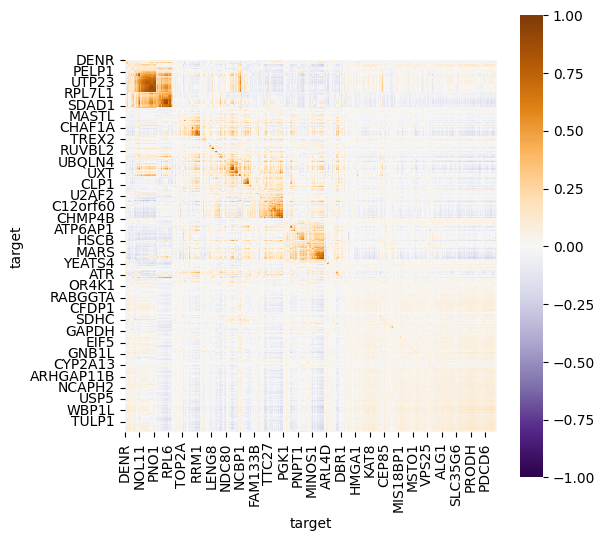

In [31]:
row_idx = heatmap.dendrogram_row.reordered_ind
f, ax = plt.subplots(figsize=(6, 6))
corr_heatmap = sns.heatmap(corr_df.iloc[:, row_idx].iloc[row_idx, :], cmap="PuOr_r", square=True, vmin=-1, vmax=1, ax=ax)
f.savefig("gwps_plots/corr_heatmap.png", dpi=300)

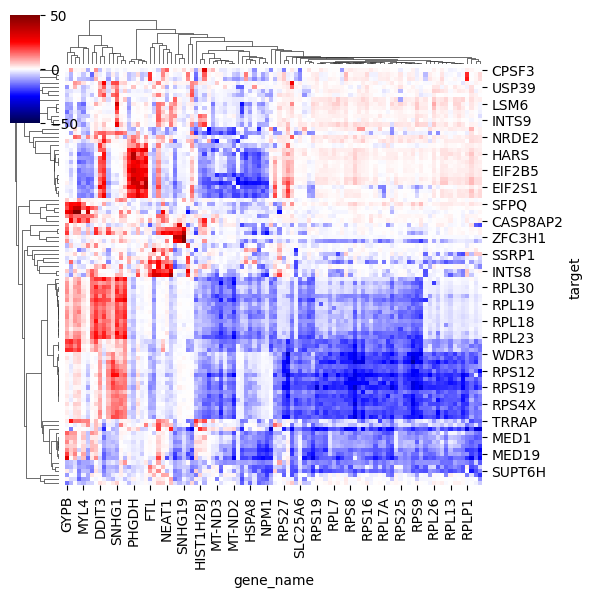

In [32]:
heatmap_subset = sns.clustermap(plot_z_df, metric="cosine", cmap="seismic", dendrogram_ratio=0.1, vmin=-50, vmax=50, figsize=(6,6))
heatmap_subset.savefig("gwps_plots/zscore_heatmap_hvg.png", dpi=300)

In [33]:
corr_subset = np.corrcoef(plot_z_df.values)
# corr_subset = squareform(pdist(plot_z_df.values, "cosine"))
corr_df_subset = pd.DataFrame(data=corr_subset,
                     columns=plot_z_df.index,
                     index=plot_z_df.index)

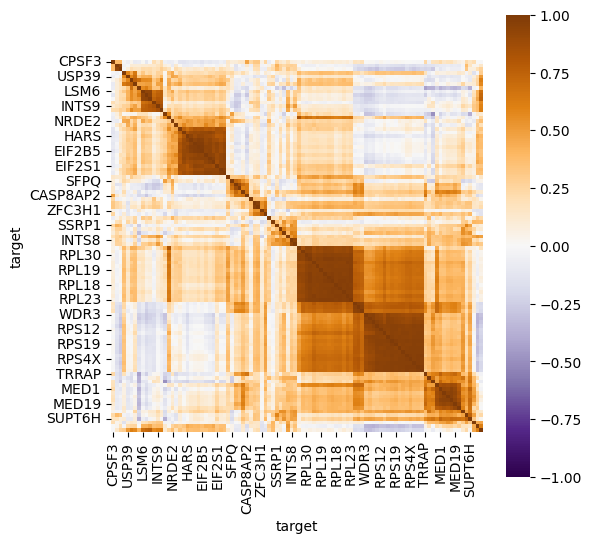

In [38]:
row_idx_subset = heatmap_subset.dendrogram_row.reordered_ind
f, ax = plt.subplots(figsize=(6, 6))
corr_heatmap_subset = sns.heatmap(corr_df_subset.iloc[:, row_idx_subset].iloc[row_idx_subset, :],
                           cmap="PuOr_r", square=True, vmin=-1, vmax=1,ax=ax)
f.savefig("gwps_plots/corr_heatmap_hvg.png", dpi=300)

## Compare targeted gene knockdown vs. all other effects 

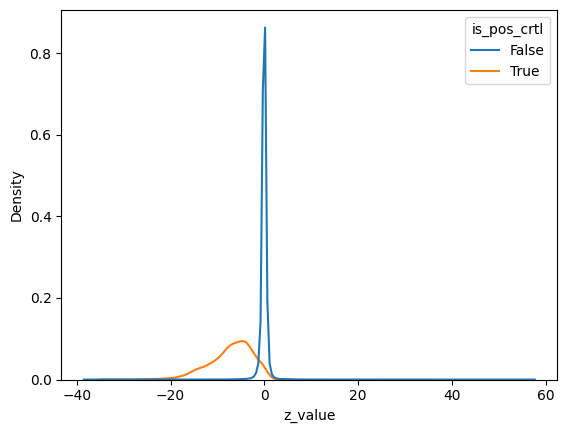

In [35]:
gwps_df=gwps_df.assign(is_pos_crtl=lambda x: x['guide']==x['gene'])
# pos_ctrls = gwps_df.query("guide==gene").sort_values("z_value")
# sns.histplot(gwps_df, x='z_value', hue='is_pos_crtl', bins=100, stat="density", common_norm=False)
sns.kdeplot(gwps_df, x='z_value', hue='is_pos_crtl', common_norm=False)

# pos_ctrls
plt.show()


In [ ]:
gwps_df=gwps_df.sort_values("z_value")
gwps_df.to_csv("K562_essential_raw_singlecell_01.csv")

In [ ]:
gwps_df

,guide,gene,z_value,is_pos_crtl
10895305,KRR1,RPS3,-38.388737,False
19434727,FASTKD5,MT-ATP6,-34.285698,False
6668300,RPS19,EEF1A1,-33.205326,False
12410384,WDR3,TPT1,-33.069458,False
17176379,RPS19,RPS19,-32.150661,True
...,...,...,...,...
2451348,NCBP2,PCBP1-AS1,49.571320,False
13897720,GAB2,HBZ,51.932728,False
14015874,EXOSC2,SNHG19,52.111626,False
14017453,ZFC3H1,SNHG19,53.986736,False
